[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/brianjalaian/CAP6606_ML_ISR/blob/main/modules/12_pytorch/ch12_part1-UWFLecture.ipynb)
[![Open in Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://kaggle.com/kernels/welcome?src=https://github.com/brianjalaian/CAP6606_ML_ISR/blob/main/modules/12_pytorch/ch12_part1-UWFLecture.ipynb)


# Chapter 12 - Parallelizing Neural Network Training with PyTorch (Part 1/2)

---

## Prework
### Import essentials

In [1]:
from IPython.display import Image
%matplotlib inline

### Check package version (optional)

Add folder to path in order to load from the `check_packages.py` script.

In [2]:
import sys
sys.path.insert(0, '..')

Check recommended package versions.

In [3]:
from python_environment_check import check_packages


d = {
    'numpy': '1.21.2',
    'matplotlib': '3.4.3',
    'torch': '1.9.0',
}
check_packages(d)

[OK] Your Python version is 3.8.0 (tags/v3.8.0:fa919fd, Oct 14 2019, 19:37:50) [MSC v.1916 64 bit (AMD64)]
[OK] numpy 1.22.3
[OK] matplotlib 3.5.1
[OK] torch 2.1.1+cpu


### Watermark (optional)

Optional watermark extension is a small IPython notebook plugin that I developed to make the code reproducible.

You can install `watermark` Jupyter extension via

    conda install watermark -c conda-forge  

or  

    pip install watermark   

For more information, please see: https://github.com/rasbt/watermark.

In [4]:
%load_ext watermark
%watermark -a "Sebastian Raschka, Johnny Yu" -u -d -v -p numpy,pandas,matplotlib,scipy,sklearn

Author: Sebastian Raschka, Johnny Yu

Last updated: 2023-12-14

Python implementation: CPython
Python version       : 3.8.0
IPython version      : 8.12.2

numpy     : 1.22.3
pandas    : 2.0.3
matplotlib: 3.5.1
scipy     : 1.8.0
sklearn   : not installed



---

## Table of Contents

- [12.1.PyTorch and training performance](#12.1.PyTorch-and-training-performance)
  - [12.1.1.Performance challenges](#12.1.1.Performance-challenges)
  - [12.1.2.What is PyTorch?](#12.1.2.What-is-PyTorch?)
  - [12.1.3.How we will learn PyTorch](#12.1.3.How-we-will-learn-PyTorch)
- [12.2.First steps with PyTorch](#12.2.First-steps-with-PyTorch)
  - [12.2.1.Installing PyTorch](#12.2.1.Installing-PyTorch)
  - [12.2.2.Creating tensors in PyTorch](#12.2.2.Creating-tensors-in-PyTorch)
  - [12.2.3.Manipulating the data type and shape of a tensor](#12.2.3.Manipulating-the-data-type-and-shape-of-a-tensor)
  - [12.2.4.Applying mathematical operations to tensors](#12.2.4.Applying-mathematical-operations-to-tensors)
  - [12.2.5.Split, stack, and concatenate tensors](#12.2.5.Split,-stack,-and-concatenate-tensors)
- [12.3.Building input pipelines in PyTorch](#12.3.Building-input-pipelines-in-PyTorch)
  - [12.3.1.Creating a PyTorch DataLoader from existing tensors](#12.3.1.Creating-a-PyTorch-DataLoader-from-existing-tensors)
  - [12.3.2.Combining two tensors into a joint dataset](#12.3.2.Combining-two-tensors-into-a-joint-dataset)
  - [12.3.3.Shuffle, batch, and repeat](#12.3.3.Shuffle,-batch,-and-repeat)
  - [12.3.4.Creating a dataset from files on your local storage disk](#12.3.4.Creating-a-dataset-from-files-on-your-local-storage-disk)
  - [12.3.5.Fetching available datasets from the torchvision.datasets library](#12.3.5.Fetching-available-datasets-from-the-torchvision.datasets-library)
  
---

## 12.1.PyTorch and training performance
### 12.1.1.Performance challenges

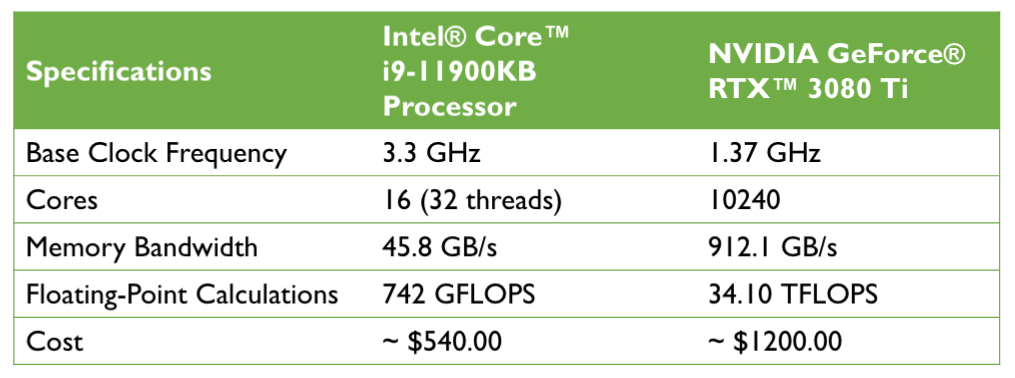

In [4]:
IPythonImage(filename='figures/12_01.png', width=500)

### 12.1.2.What is PyTorch?
- PyTorch is built around a computation graph composed of a set of nodes. 
- Each node represents an operation that may have zero or more inputs or outputs.
- Tensors in PyTorch are similar to NumPy’s arrays, except that tensors are optimized for automatic differentiation and can run on GPUs.
- Tensors can be understood as a generalization of scalars, vectors, matrices, and so on.
	- scalar: rank-0 tensor
	- vector: rank-1 tensor
	- matrix: rank-2 tensor
	- matrices stack in 3rd dimension: rank-3 tensors

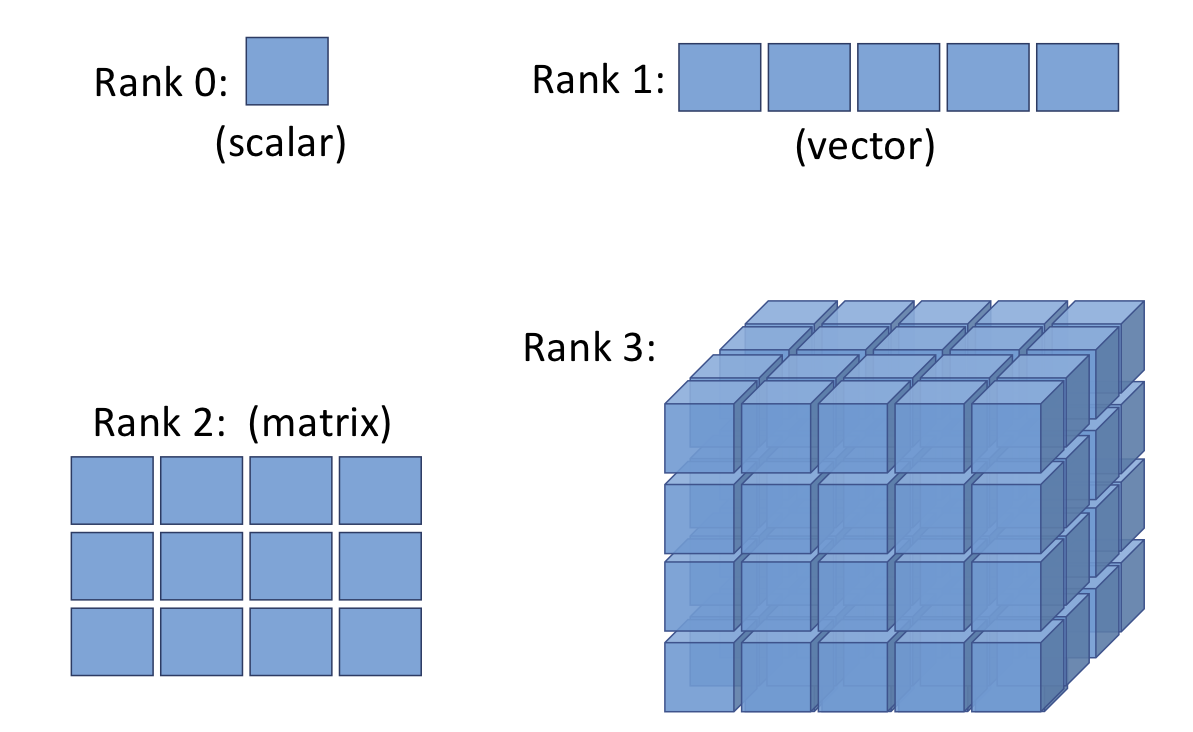

In [5]:
IPythonImage(filename='figures/12_02.png', width=500)

### 12.1.3.How we will learn PyTorch
No code provided.

<br>

---

## 12.2.First steps with PyTorch
### 12.2.1.Installing PyTorch

In [6]:
#! pip install torch

In [5]:
import torch
import numpy as np

print('PyTorch version:', torch.__version__)

np.set_printoptions(precision=3)

PyTorch version: 2.1.1+cpu


In [8]:
! python -c 'import torch; print(torch.__version__)'

1.10.0


### 12.2.2.Creating tensors in PyTorch
Firstly, we can simply create a tensor from a list or a NumPy array using the `torch.tensor` or the `torch.from_numpy` function as follows.

In [6]:
a = [1, 2, 3]
b = np.array([4, 5, 6], dtype=np.int32)

t_a = torch.tensor(a)
t_b = torch.from_numpy(b)

print(t_a)
print(t_b)

tensor([1, 2, 3])
tensor([4, 5, 6], dtype=torch.int32)


Similar to NumPy arrays, we can also see these properties.

In [10]:
torch.is_tensor(a), torch.is_tensor(t_a)

(False, True)

In [8]:
t_ones = torch.ones(2, 3)
print(t_ones.shape)
print(t_ones)

torch.Size([2, 3])
tensor([[1., 1., 1.],
        [1., 1., 1.]])


Finally, creating a tensor of random values can be done as follows.

In [9]:
rand_tensor = torch.rand(2,3)

print(rand_tensor)

tensor([[0.4390, 0.4228, 0.1732],
        [0.0834, 0.0659, 0.5497]])


### 12.2.3.Manipulating the data type and shape of a tensor
The `torch.to()` function can be used to change the data type of a tensor to a desired type.

In [11]:
t_a_new = t_a.to(torch.int64)

print(t_a_new.dtype)

torch.int64


Certain operations require that the input tensors have a certain number of dimensions (that is, rank) associated with a certain number of elements (shape). Thus, we might need to change the shape of a tensor, add a new dimension, or squeeze an unnecessary dimension. PyTorch provides useful functions (or operations) to achieve this:

1) Transposing a tensor.

In [12]:
t = torch.rand(3, 5)

t_tr = torch.transpose(t, 0, 1)
print(t.shape, ' --> ', t_tr.shape)

torch.Size([3, 5])  -->  torch.Size([5, 3])


2) Reshaping a tensor (for example, from a 1D vector to a 2D array).

In [13]:
t = torch.zeros(30)

t_reshape = t.reshape(5, 6)

print(t_reshape.shape)

torch.Size([5, 6])


3) Removing the unnecessary dimensions (dimensions that have size 1, which are not needed).

In [14]:
t = torch.zeros(1, 2, 1, 4, 1)

t_sqz = torch.squeeze(t, 2)

print(t.shape, ' --> ', t_sqz.shape)

torch.Size([1, 2, 1, 4, 1])  -->  torch.Size([1, 2, 4, 1])


### 12.2.4.Applying mathematical operations to tensors
In this subsection, we will cover some widely used linear algebra operations. First, let’s instantiate two random tensors, one with uniform distribution in the range `[–1, 1)` and the other with a standard normal distribution.

Note that `torch.rand` returns a tensor filled with random numbers from a uniform distribution in the range of `[0, 1)`. Also, notice that `t1` and `t2` have the same shape. 

In [15]:
torch.manual_seed(1)

t1 = 2 * torch.rand(5, 2) - 1
t2 = torch.normal(mean=0, std=1, size=(5, 2))

Now, to compute the element-wise product of `t1` and `t2`, we can use the following.

In [16]:
t3 = torch.multiply(t1, t2)
print(t3)

tensor([[ 0.4426, -0.3114],
        [ 0.0660, -0.5970],
        [ 1.1249,  0.0150],
        [ 0.1569,  0.7107],
        [-0.0451, -0.0352]])


The mean of each column in `t1` can be computed as follows.

In [17]:
t4 = torch.mean(t1, axis=0)
print(t4)

tensor([-0.1373,  0.2028])


The matrix-matrix product between `t1` and `t2` (that is, $t_1 \times t_2^{\mathrm{T}}$, where the superscript T is for transpose) can be computed by using the `torch.matmul()` function as follows.

In [18]:
t5 = torch.matmul(t1, torch.transpose(t2, 0, 1))

print(t5)

tensor([[ 0.1312,  0.3860, -0.6267, -1.0096, -0.2943],
        [ 0.1647, -0.5310,  0.2434,  0.8035,  0.1980],
        [-0.3855, -0.4422,  1.1399,  1.5558,  0.4781],
        [ 0.1822, -0.5771,  0.2585,  0.8676,  0.2132],
        [ 0.0330,  0.1084, -0.1692, -0.2771, -0.0804]])


On the other hand, computing $t_1^T \times t_2$ is performed by transposing `t1`, resulting in an array of size 2×2.

In [19]:
t6 = torch.matmul(torch.transpose(t1, 0, 1), t2)

print(t6)

tensor([[ 1.7453,  0.3392],
        [-1.6038, -0.2180]])


Finally, the `torch.linalg.norm()` function is useful for computing the $L^p$ norm of a tensor. For example, we can calculate the $L^2$ norm of `t1` as follows.

In [20]:
norm_t1 = torch.linalg.norm(t1, ord=2, dim=1)

print(norm_t1)

tensor([0.6785, 0.5078, 1.1162, 0.5488, 0.1853])


To verify that this code snippet computes the $L^2$ norm of `t1` correctly, you can compare the results with the following NumPy function.

In [21]:
np.sqrt(np.sum(np.square(t1.numpy()), axis=1))

array([0.678, 0.508, 1.116, 0.549, 0.185], dtype=float32)

### 12.2.5.Split, stack, and concatenate tensors
Assume that we have a single tensor, and we want to split it into two or more tensors. For this, PyTorch provides a convenient `torch.chunk()` function, which divides an input tensor into a list of equally sized tensors. We can determine the desired number of splits as an integer using the `chunks` argument to split a tensor along the desired dimension specified by the `dim` argument. In this case, the total size of the input tensor along the specified dimension must be divisible by the desired number of splits. Alternatively, we can provide the desired sizes in a list using the `torch.split()` function. Let's have a look at an example of both these options:

1) Providing the number of splits: `torch.chunk()`
	- In this example, a tensor of size 6 was divided into a list of three tensors each with size 2. If the tensor size is not divisible by the `chunks` value, the last chunk will be smaller.

In [22]:
torch.manual_seed(1)

t = torch.rand(6)

print(t)

t_splits = torch.chunk(t, 3)

[item.numpy() for item in t_splits]

tensor([0.7576, 0.2793, 0.4031, 0.7347, 0.0293, 0.7999])


[array([0.758, 0.279], dtype=float32),
 array([0.403, 0.735], dtype=float32),
 array([0.029, 0.8  ], dtype=float32)]

2) Providing the sizes of different splits: `torch.split()`
	- Alternatively, instead of defining the number of splits, we can also specify the sizes of the output tensors directly. Here, we are splitting a tensor of size 5 into tensors of sizes 3 and 2.

In [23]:
torch.manual_seed(1)
t = torch.rand(5)

print(t)

t_splits = torch.split(t, split_size_or_sections=[3, 2])
 
[item.numpy() for item in t_splits]

tensor([0.7576, 0.2793, 0.4031, 0.7347, 0.0293])


[array([0.758, 0.279, 0.403], dtype=float32),
 array([0.735, 0.029], dtype=float32)]

Sometimes, we are working with multiple tensors and need to concatenate or stack them to create a single tensor. In this case, PyTorch functions such as `torch.stack()` and `torch.cat()` come in handy. 

1) Concatenate tensors: `torch.cat()`
    - For example, let’s create a 1D tensor, `A`, containing 1s with size 3, and a 1D tensor, `B`, containing 0s with size 2, and concatenate them into a 1D tensor, `C`, of size 5.

In [24]:
A = torch.ones(3)
B = torch.zeros(2)

C = torch.cat([A, B], axis=0)
print(C)

tensor([1., 1., 1., 0., 0.])


2) Stack tensors: `torch.stack()`
	- If we create 1D tensors `A` and `B`, both with size 3, then we can stack them together to form a 2D tensor, `S`.

In [25]:
A = torch.ones(3)
B = torch.zeros(3)

S = torch.stack([A, B], axis=1)
print(S)

tensor([[1., 0.],
        [1., 0.],
        [1., 0.]])


<br>

---

## 12.3.Building input pipelines in PyTorch
### 12.3.1.Creating a PyTorch DataLoader from existing tensors
If the data already exists in the form of a tensor object, a Python list, or a NumPy array, we can easily create a dataset loader using the `torch.utils.data.DataLoader()` class. It returns an object of the `DataLoader` class, which we can use to iterate through the individual elements in the input dataset. As a simple example, consider the following code, which creates a dataset from a list of values from 0 to 5.

In [28]:
from torch.utils.data import DataLoader


t = torch.arange(6, dtype=torch.float32)
data_loader = DataLoader(t)

We can easily iterate through a dataset entry by entry as follows.

In [29]:
for item in data_loader:
    print(item)

tensor([0.])
tensor([1.])
tensor([2.])
tensor([3.])
tensor([4.])
tensor([5.])


If we want to create batches from this dataset, with a desired batch size of 3, we can do this with the `batch_size` argument as follows. The optional ``drop_last`` argument is useful for cases when the number of elements in the tensor is not divisible by the desired batch size. The default value for `drop_last` is `False`.

In [32]:
data_loader = DataLoader(t, batch_size=3, drop_last=False)

for i, batch in enumerate(data_loader, 1):
    print(f'batch {i}:', batch)

batch 1: tensor([0., 1., 2.])
batch 2: tensor([3., 4., 5.])


### 12.3.2.Combining two tensors into a joint dataset
Often, we may have the data in two (or possibly more) tensors. For example, we could have a tensor for features and a tensor for labels. In such cases, we need to build a dataset that combines these tensors, which will allow us to retrieve the elements of these tensors in tuples.

Note that a common source of error could be that the element-wise correspondence between the original features ($x$) and labels ($y$) might be lost (for example, if the two datasets are shuffled separately). However, once they are merged into one dataset, it is safe to apply these operations.

Assume that we have two tensors, `t_x` and `t_y`:
- `t_x` holds our feature values, each of size 3
- `t_y` stores the class labels

In [33]:
torch.manual_seed(1)

t_x = torch.rand([4, 3], dtype=torch.float32)
t_y = torch.arange(4)

We want to create a joint dataset from these two tensors. We first need to create a `Dataset` class as follows. A custom `Dataset` class must contain the following methods to be used by the data loader later on:
- `__init__()`: This is where the initial logic happens, such as reading existing arrays, loading a file, filtering data, and so forth.
- `__getitem__()`: This returns the corresponding sample to the given index.

In [34]:
from torch.utils.data import Dataset


class JointDataset(Dataset):
    def __init__(self, x, y):
        self.x = x
        self.y = y
    def __len__(self):
        return len(self.x)
    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

Then we create a joint dataset of `t_x` and `t_y` with the custom `Dataset` class and print each example of the joint dataset as follows.

In [35]:
joint_dataset = JointDataset(t_x, t_y)

for example in joint_dataset:
    print('  x: ', example[0], 
          '  y: ', example[1])

  x:  tensor([0.7576, 0.2793, 0.4031])   y:  tensor(0)
  x:  tensor([0.7347, 0.0293, 0.7999])   y:  tensor(1)
  x:  tensor([0.3971, 0.7544, 0.5695])   y:  tensor(2)
  x:  tensor([0.4388, 0.6387, 0.5247])   y:  tensor(3)


We can also simply utilize the `torch.utils.data.TensorDataset` class, if the second dataset is a labeled dataset in the form of tensors. So, instead of using our self-defined `Dataset` class, `JointDataset`, we can create a joint dataset as follows.

In [36]:
from torch.utils.data import TensorDataset


joint_dataset = TensorDataset(t_x, t_y)

### 12.3.3.Shuffle, batch, and repeat
When training an NN model using stochastic gradient descent optimization, it is important to feed training data as randomly shuffled batches. You have already seen how to specify the batch size using the `batch_size` argument of a data loader object. Now, in addition to creating batches, you will see how to shuffle and reiterate over the datasets. We will continue working with the previous joint dataset.

First, let’s create a shuffled version data loader from the `joint_dataset` dataset. Here, each batch contains two data records ($x$) and the corresponding labels ($y$). Now we iterate through the data loader entry by entry.

**Result explanation**

The rows are shuffled without losing the one-to-one correspondence between the entries in `x` and `y`. 

In [37]:
torch.manual_seed(1)
data_loader = DataLoader(dataset=joint_dataset, batch_size=2, shuffle=True)

for i, batch in enumerate(data_loader, 1):
        print(f'batch {i}:', 'x:', batch[0], 
              '\n         y:', batch[1])

batch 1: x: tensor([[0.3971, 0.7544, 0.5695],
        [0.7576, 0.2793, 0.4031]]) 
         y: tensor([2, 0])
batch 2: x: tensor([[0.7347, 0.0293, 0.7999],
        [0.4388, 0.6387, 0.5247]]) 
         y: tensor([1, 3])


In addition, when training a model for multiple epochs, we need to shuffle and iterate over the dataset by the desired number of epochs. So, let’s iterate over the batched dataset twice.

**Result explanation**

- The first epoch: 
	- the first batch contains a pair of values `[y=1, y=2]`, and the second batch contains a pair of values `[y=3, y=0]`. 
- The second epoch:
	- two batches contain a pair of values, `[y=2, y=0]` and `[y=1, y=3]` respectively. For each iteration, the elements within a batch are also shuffled.

In [38]:
for epoch in range(2):
    print(f'epoch {epoch+1}')
    for i, batch in enumerate(data_loader, 1):
        print(f'batch {i}:', 'x:', batch[0], 
              '\n         y:', batch[1])

epoch 1
batch 1: x: tensor([[0.7576, 0.2793, 0.4031],
        [0.3971, 0.7544, 0.5695]]) 
         y: tensor([0, 2])
batch 2: x: tensor([[0.7347, 0.0293, 0.7999],
        [0.4388, 0.6387, 0.5247]]) 
         y: tensor([1, 3])
epoch 2
batch 1: x: tensor([[0.4388, 0.6387, 0.5247],
        [0.3971, 0.7544, 0.5695]]) 
         y: tensor([3, 2])
batch 2: x: tensor([[0.7576, 0.2793, 0.4031],
        [0.7347, 0.0293, 0.7999]]) 
         y: tensor([0, 1])


### 12.3.4.Creating a dataset from files on your local storage disk
In this section, we will build a dataset from image files stored on disk. There is an image folder associated with the online content of this chapter. After downloading the folder, you should be able to see six images of cats and dogs in JPEG format.

This small dataset will show how building a dataset from stored files generally works. To accomplish this, we are going to use two additional modules: 
1. `Image` in `PIL` to read the image file contents 
2. `transforms` in `torchvision` to decode the raw contents and resize the images

Before we start, let’s take a look at the content of these files. We will use the `pathlib` library to generate a list of image files.

In [39]:
import pathlib

imgdir_path = pathlib.Path('cat_dog_images')

file_list = sorted([str(path) for path in imgdir_path.glob('*.jpg')])

print(file_list)

['cat_dog_images\\cat-01.jpg', 'cat_dog_images\\cat-02.jpg', 'cat_dog_images\\cat-03.jpg', 'cat_dog_images\\dog-01.jpg', 'cat_dog_images\\dog-02.jpg', 'cat_dog_images\\dog-03.jpg']


Next, we will visualize these image examples using Matplotlib.

**Result explanation**


Just from this visualization and the printed image shapes, we can already see that the images have different aspect ratios. If you print the aspect ratios (or data array shapes) of these images, you will see that some images are 900 pixels high and 1200 pixels wide $(900 \times 1200)$, some are $800 \times 1200$, and one is $900 \times 742$. Later, we will preprocess these images to a consistent size. 

Image shape:  (900, 1200, 3)
Image shape:  (900, 1200, 3)
Image shape:  (900, 742, 3)
Image shape:  (800, 1200, 3)
Image shape:  (800, 1200, 3)
Image shape:  (900, 1200, 3)


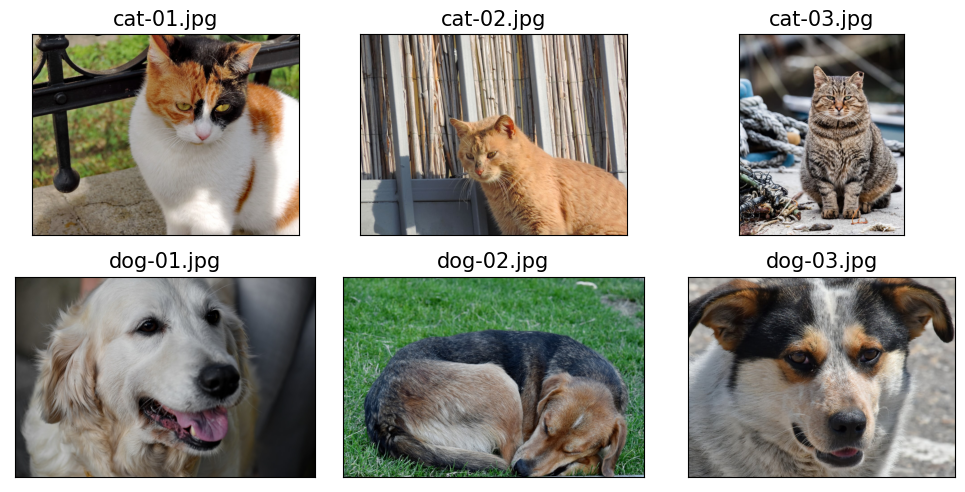

In [40]:
import matplotlib.pyplot as plt
import os
from PIL import Image


fig = plt.figure(figsize=(10, 5))
for i, file in enumerate(file_list):
    img = Image.open(file)
    print('Image shape: ', np.array(img).shape)
    ax = fig.add_subplot(2, 3, i+1)
    ax.set_xticks([]); ax.set_yticks([])
    ax.imshow(img)
    ax.set_title(os.path.basename(file), size=15)
    
#plt.savefig('figures/12_03.pdf')
plt.tight_layout()
plt.show()

Another point to consider is that the labels for these images are provided within their filenames. So, we extract these labels from the list of filenames, assigning label 1 to dogs and label 0 to cats.

In [42]:
labels = [1 if 'dog' in os.path.basename(file) else 0
          for file in file_list]
print(labels)

[0, 0, 0, 1, 1, 1]


Now, we have two lists: 
1. a list of filenames (or paths of each image) 
2. a list of their labels

In the previous section, you learned how to create a customized joint dataset from two arrays, we are going to create a joint dataset for them, where the joint dataset has filenames and labels.

In [43]:
class ImageDataset(Dataset):
    def __init__(self, file_list, labels):
        self.file_list = file_list
        self.labels = labels

    def __getitem__(self, index):
        file = self.file_list[index]      
        label = self.labels[index]
        return file, label

    def __len__(self):
        return len(self.labels)
    
image_dataset = ImageDataset(file_list, labels)
for file, label in image_dataset:
    print(file, label)

cat_dog_images\cat-01.jpg 0
cat_dog_images\cat-02.jpg 0
cat_dog_images\cat-03.jpg 0
cat_dog_images\dog-01.jpg 1
cat_dog_images\dog-02.jpg 1
cat_dog_images\dog-03.jpg 1


Next, we need to apply transformations to this dataset: 
- load the image content from its file path
- decode the raw content
- resize it to a desired size, for example, $80 \times 120$

As mentioned before, we use the `torchvision.transforms` module to resize the images and convert the loaded pixels into tensors as follows.

In [44]:
import torchvision.transforms as transforms


img_height, img_width = 80, 120
    
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((img_height, img_width)),
])

Now we update the `ImageDataset` class with the transform we just defined.

The `__getitem__` method in the `ImageDataset` class wraps all four steps into a single function, including:
- the loading of the raw content (images and labels)
- decoding the images into tensors
- resizing the images. 

The function then returns a dataset that we can iterate over and apply other operations that we learned about in the previous sections via a data loader, such as shuffling and batching.

In [45]:
class ImageDataset(Dataset):
    def __init__(self, file_list, labels, transform=None):
        self.file_list = file_list
        self.labels = labels
        self.transform = transform
    def __getitem__(self, index):
        img = Image.open(self.file_list[index])        
        if self.transform is not None:
            img = self.transform(img)
        label = self.labels[index]
        return img, label
    def __len__(self):
        return len(self.labels)

image_dataset = ImageDataset(file_list, labels, transform)

Finally, we visualize these transformed image examples using Matplotlib. This results in the following visualization of the retrieved example images, along with their labels.

c:\Users\902to\AppData\Local\Programs\Python\Python38\lib\site-packages\torchvision\transforms\functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


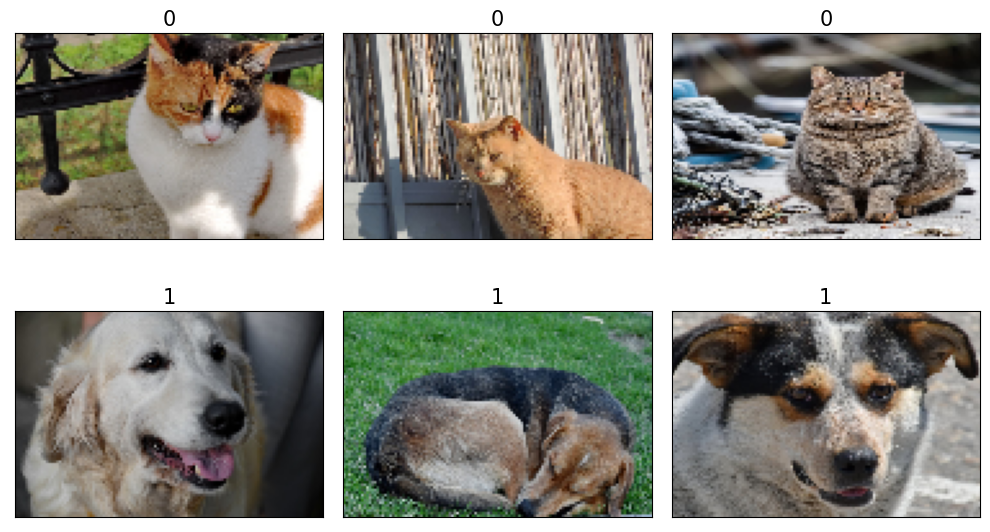

In [46]:
fig = plt.figure(figsize=(10, 6))
for i, example in enumerate(image_dataset):
    ax = fig.add_subplot(2, 3, i+1)
    ax.set_xticks([]); ax.set_yticks([])
    ax.imshow(example[0].numpy().transpose((1, 2, 0)))
    ax.set_title(f'{example[1]}', size=15)
    
plt.tight_layout()
plt.savefig('figures/12_04.pdf')
plt.show()

### 12.3.5.Fetching available datasets from the torchvision.datasets library

In [41]:
# ! pip install torchvision

---
**Fetching CelebA dataset**

1. Downloading the image files manually

    - You can try setting `download=True` below. If this results in a `BadZipfile` error, we recommend downloading the `img_align_celeba.zip` file manually from http://mmlab.ie.cuhk.edu.hk/projects/CelebA.html. In the Google Drive folder, you can find it under the `Img` folder as shown below:

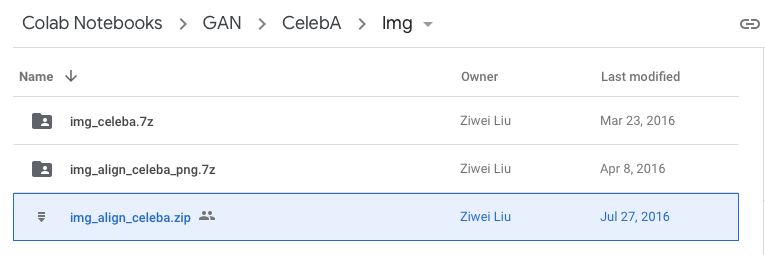

In [43]:
IPythonImage(filename='figures/gdrive-download-location-1.png', width=500)

- You can also try this direct  link: https://drive.google.com/file/d/0B7EVK8r0v71pZjFTYXZWM3FlRnM/view?usp=sharing&resourcekey=0-dYn9z10tMJOBAkviAcfdyQ
- After downloading, please put this file into the `./celeba` subolder and unzip it.

2. Next,  you need to download the annotation files and put them into the same `./celeba` subfolder. The annotation files can be found under `Anno`:

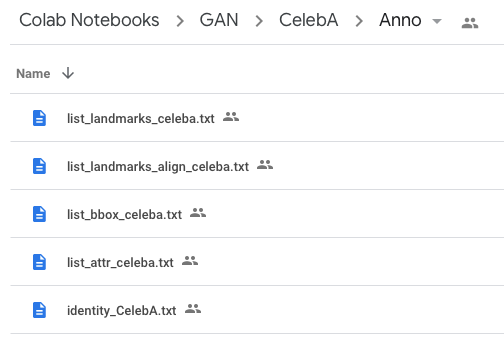

In [44]:
IPythonImage(filename='figures/gdrive-download-location-2.png', width=300)

- direct links are provided below:
  - [identity_CelebA.txt](https://drive.google.com/file/d/1_ee_0u7vcNLOfNLegJRHmolfH5ICW-XS/view?usp=sharing)
  - [list_attr_celeba.txt](https://drive.google.com/file/d/0B7EVK8r0v71pblRyaVFSWGxPY0U/view?usp=sharing&resourcekey=0-YW2qIuRcWHy_1C2VaRGL3Q)
  - [list_bbox_celeba.txt](https://drive.google.com/file/d/0B7EVK8r0v71pbThiMVRxWXZ4dU0/view?usp=sharing&resourcekey=0-z-17UMo1wt4moRL2lu9D8A)
  - [list_landmarks_align_celeba.txt](https://drive.google.com/file/d/0B7EVK8r0v71pd0FJY3Blby1HUTQ/view?usp=sharing&resourcekey=0-aFtzLN5nfdhHXpAsgYA8_g)
  - [list_landmarks_celeba.txt](https://drive.google.com/file/d/0B7EVK8r0v71pTzJIdlJWdHczRlU/view?usp=sharing&resourcekey=0-49BtYuqFDomi-1v0vNVwrQ)

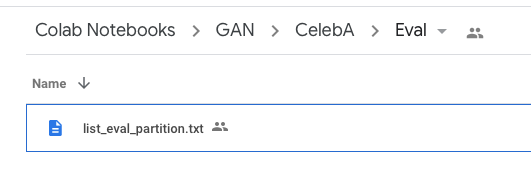

In [45]:
IPythonImage(filename='figures/gdrive-download-location-3.png', width=300)

3. Lastly, you need to download the file `list_eval_partition.txt` and place it under `./celeba`:

- [list_eval_partition.txt](https://drive.google.com/file/d/0B7EVK8r0v71pY0NSMzRuSXJEVkk/view?usp=sharing&resourcekey=0-i4TGCi_51OtQ5K9FSp4EDg)

After completing steps 1-3 above, please ensure you have the following files in your `./celeba` subfolder, and the files are non-empty (that is, they have similar file sizes as shown below):

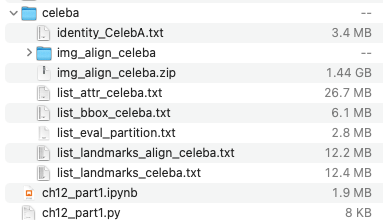

In [46]:
IPythonImage(filename='figures/celeba-files.png', width=400)

---
The following paragraphs include two different datasets: 1. CelebA dataset 2. MINST dataset

<br>

**1. CelebA dataset**

The `torchvision.datasets` library provides a nice collection of freely available image datasets for 
training or evaluating deep learning models. Similarly, the `torchtext.datasets` library provides 
datasets for natural language. Here, we use `torchvision.datasets` as an example.

Let’s first work with the `CelebA` dataset with `torchvision.datasets.CelebA`. The description of `torchvision.datasets.CelebA` provides some useful information to help us understand the structure of this dataset:
- The database has three subsets, `'train'`, `'valid'`, and `'test'`.
	- We can select a specific subset or load all of them with the split parameter.
- The images are stored in `PIL.Image` format. 
	- We can obtain a transformed version using a custom transform function, such as `transforms.ToTensor` and `transforms.Resize`. 
- There are different types of targets we can use, including `'attributes'`, `'identity'`, and `'landmarks'`. 
	- `'attributes'` is 40 facial attributes for the person in the image, such as facial expression, makeup, hair properties ...
	- `'identity'` is the person ID for an image.
	- `'landmarks'` refers to the dictionary of extracted facial points, such as the position of the eyes, nose ...

Next, we will call the `torchvision.datasets.CelebA` class to download the data, store it on disk in a designated folder, and load it into a `torch.utils.data.Dataset` object. After we have instantiated the datasets, let’s check if the object is of the `torch.utils.data.Dataset` class via function `isinstance()`.

In [ ]:
import torchvision


image_path = './'
celeba_dataset = torchvision.datasets.CelebA(image_path, split='train', target_type='attr', download=False)

assert isinstance(celeba_dataset, torch.utils.data.Dataset)

As mentioned, the dataset is already split into train, test, and validation datasets, and we only load the train set. And we only use the `'attributes'` target. In order to see what the data examples look like, we can execute the following code.

Note that the sample in this dataset comes in a tuple of (`PIL.Image, attributes`). If we want to pass this dataset to a supervised deep learning model during training, we have to reformat it as a tuple of (`features tensor, label`). For the label, we will use the `'Smiling'` category from the attributes as an example, which is the 31st element.

In [48]:
example = next(iter(celeba_dataset))
print(example)

(<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=178x218 at 0x1332FD850>, tensor([0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0,
        1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1]))


Finally, let’s take the first 18 examples from it to visualize them with their `'Smiling'` labels, which are retrieved from `celeba_dataset`.

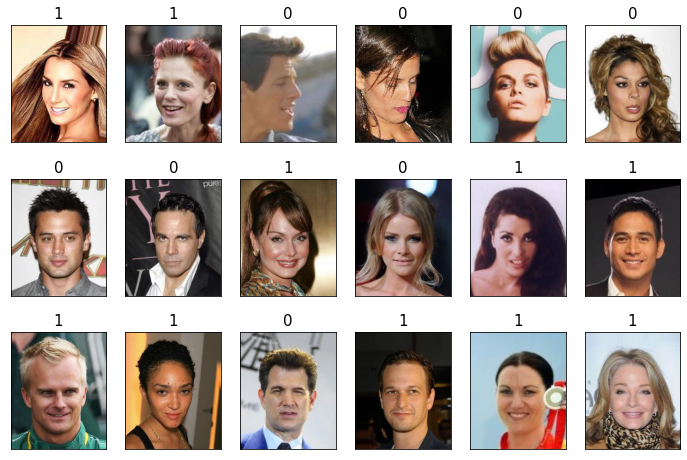

In [49]:
from itertools import islice
fig = plt.figure(figsize=(12, 8))
for i, (image, attributes) in islice(enumerate(celeba_dataset), 18):
    ax = fig.add_subplot(3, 6, i+1)
    ax.set_xticks([]); ax.set_yticks([])
    ax.imshow(image)
    ax.set_title(f'{attributes[31]}', size=15)
    
#plt.savefig('figures/12_05.pdf')
plt.show()

**2. MINST dataset**

Next, we will proceed with the second dataset from `torchvision.datasets.MNIST`. Let’s see how it can be used to fetch the MNIST digit dataset:
- The database has two partitions, `'train'` and `'test'`. 
	- We need to select a specific subset to load.
- The images are stored in `PIL.Image` format. 
	- We can obtain a transformed version using a custom transform function, such as `transforms.ToTensor` and `transforms.Resize`.
- There are 10 classes for the target, from 0 to 9.

Now, we can download the 'train' partition, convert the elements to tuples, and visualize 10 examples.

(<PIL.Image.Image image mode=L size=28x28 at 0x1317A9E80>, 5)


/Users/sebastian/miniforge3/lib/python3.9/site-packages/torchvision/datasets/mnist.py:498: UserWarning: The given NumPy array is not writeable, and PyTorch does not support non-writeable tensors. This means you can write to the underlying (supposedly non-writeable) NumPy array using the tensor. You may want to copy the array to protect its data or make it writeable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at  /Users/runner/miniforge3/conda-bld/pytorch-recipe_1635217266490/work/torch/csrc/utils/tensor_numpy.cpp:189.)
  return torch.from_numpy(parsed.astype(m[2], copy=False)).view(*s)


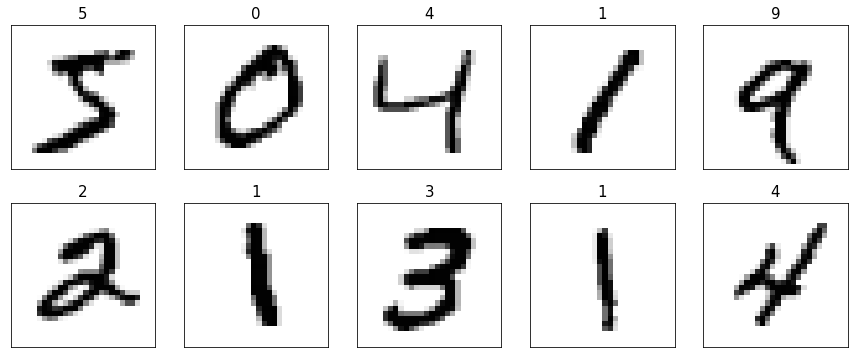

In [50]:
mnist_dataset = torchvision.datasets.MNIST(image_path, 'train', download=True)

assert isinstance(mnist_dataset, torch.utils.data.Dataset)

example = next(iter(mnist_dataset))
print(example)

fig = plt.figure(figsize=(15, 6))
for i, (image, label) in islice(enumerate(mnist_dataset), 10):
    ax = fig.add_subplot(2, 5, i+1)
    ax.set_xticks([]); ax.set_yticks([])
    ax.imshow(image, cmap='gray_r')
    ax.set_title(f'{label}', size=15)

#plt.savefig('figures/12_06.pdf')
plt.show()

---

Readers may ignore the next cell.

In [51]:
! python ../.convert_notebook_to_script.py --input ch12_part1.ipynb --output ch12_part1.py

[NbConvertApp] WARNING | Config option `kernel_spec_manager_class` not recognized by `NbConvertApp`.
[NbConvertApp] Converting notebook ch12_part1.ipynb to script
[NbConvertApp] Writing 11605 bytes to ch12_part1.py
